# <center>Self-organized criticality on complex networks</center>
### <center>Models and Numerical Methods in Physics</center>
### <center>Riccardo Grandicelli</center>

## 1. Introduction

In nature, power-laws appear everywhere. The distribution of earthquake magnitudes, of sizes of solar flares, or of wealth in a country are just a few examples of power laws. The main characteristic of power law distributions is that they are scale invariant: if you multiply the variable by a constant factor, the distribution remains identical except for a multiplicative constant factor. This means that if you "zoom" on a power law, the shape of the distribution does not change.

Two other important phenomena related to scale invariance are fractals and "1/f" noise. Fractals are self-similar geometrical structures, while "1/f" noise is a signal in which the amplitudes of frequency components follow a power-law (so it represents scale invariance in time). Both of them are very common in nature: mountain landscapes and coastal lines are example of fractal structures, while "1/f" noise have been measured in electronic devices and in the luminosity of stars.

Seeking an explanation for this common behaviour of very different systems, in 1987 Bak, Tang and Wiesenfeld [1] first talked about "self-organized criticality" (SOC). With this term they meant the ability of many dynamical systems to reach autonomously a critical state. The word "criticality" is used in analogy with the critical point at phase transitions in statistical mechanics: indeed, at the critical point the system becomes scale invariant, and power laws start to appear. However, while the reaching of a critical point in statistical mechanics requires the tuning of a parameter (such as the temperature, for example), in self-organized systems the critical point is reached as an attractor of the dynamics, without the tuning of a parameter.

In the same paper, Bak, Tang and Wiesenfeld developed a simple model, called "sandpile model", to show an example of SOC. The model is a cellular automaton that tries to emulate a pile of sand, in which a new grain of sand is added at each time step.

The model is structured as follows:
* we have a 2-dimensional square grid of N x N cells
* we assign an initial value of grains on each cell: $z(x,y) \in \{0, 1, 2, 3\}$
* at each time step $i \in \mathbb{N}$, we choose a random cell $(x, y)$ and we put one grain of sand on it: $z_i(x, y) = z_{i-1}(x, y) + 1$
* if $z_i \geq 4$ (4 is the threshold height), the cell topples: it loses 4 grains and redistributes them among its four neighbours (along the horizontal and vertical directions), giving one grain to each neighbour
* the toppling of a node can cause another of its neighbours to topple, giving raise to a cascade process called avalanche

Through a numerical simulation it is possible to show that after a certain number of time steps, the system reaches a stationary state in which the avalanche size distribution (the avalanche size is the number of topplings at a certain time step) follows a power law:

\begin{equation}

P(s) \propto s^{-\tau}

\end{equation}

which signals the presence of SOC.

In their original model, Bak, Tang and Wiesenfeld only considered a 2-d square lattice. So, the first natural idea to generalize this model was to consider network topologies different from the square lattice. Many papers have been written about this topic: in this project, we want to review the main results concerning SOC on different network topologies.

The work is structured as follows:

For the simulations, we will use two main Python packages. The first one is `networkx`, the most famous Python package to build networks. The other one, developed by me, is called `SandNet`: it allows to build a sandpile model over an arbitrary network structure. The instructions for the installation of the two packages are in the [`README.md`](https://github.com/riccardo03-maker/SOC_on_networks/blob/main/README.md) file of the GitHub repository with this project.

In [1]:
import networkx as nx
import numpy as np
import SandNet

## 2. Sandpile on a 2d square lattice

We first begin by studying the original sandpile model developed by Bak, Tang and Wiesenfeld (1987) [1]. We will use a 100 x 100 grid with open boundaries, with a fixed threshold of 4 for each node, and a random initial number of grains for each node at the beginning. We create the model using the `SandNet.Model` object, and evolve it for 30000 time steps by adding new grains in random positions.

In [ ]:
original_model = SandNet.Model(N = 100, initial_grains='random', seed = 42)
#the threshold of 4 and the lattice topologies are default parameters, so we don't need to specify them

original_model.evolve(30000)

Then we can plot the avalanche size distribution, and fit it to a power law:

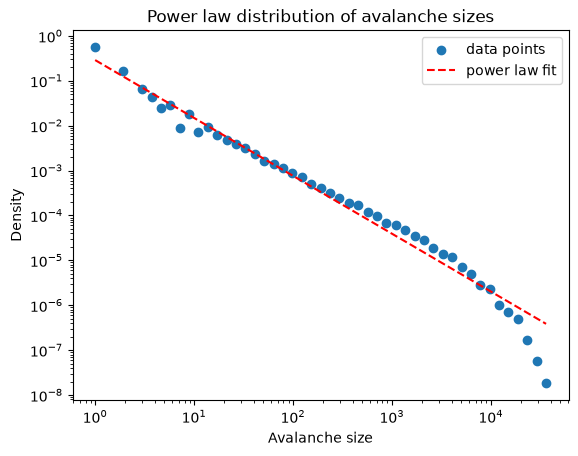

Avalanche size exponent: 0.2891527249266174


In [ ]:
exponent = SandNet.fit_avalanche_size(original_model)
print("Avalanche size exponent: " + str(exponent))

As we can read in the [SandNet documentation](https://sandnet.readthedocs.io/en/latest/API/plots.html), the exponent returned by the `plot_avalanche_size` function is lowered by 1 with respect to the exponent in (1). This happens because the real form of the function used for the fit is the Pareto distribution:

\begin{equation}

P(x) = \frac{b}{x^{b+1}}

\end{equation}

and the parameter returned by the `plot_avalanche_size` function is $b$, while comparing (2) with (1) we see that the exponent $\tau$ is given by $b+1$.

So, we can see that the system organizes into a critical state, with a distribution of avalanche sizes well fitted by a power law of the form (1) with the exponent $\tau \approx 1.28$. In the next section we will see an analytical derivation of this exponent, and we will compare the value obtained through simulations with the one we will obtain theoretically.

It is worth noting that, when a node on the boundaries of the grid topples, it loses four grains, but it only has three (if it is on a side of the grid) or two (if it is a vertex of the grid) neighbours. Since the system has open boundaries, one or two grains are lost after the toppling of boundary nodes. If we didn't have dissipation of grains, the total number of grains in the system would always grow by 1 at each time step, until we would reach a point in which the system is saturated and it remains locked into an avalanche of infinite size. So, having open boundaries is essential to have a self-organized critical state. 

## 3. Mean field treatment of sandpile model

The simplest approach to describe SOC theoretically is the mean field theory, which provides an approximation of the exponent for avalanche size distribution.

Each avalanche event in the sandpile model can be represented as a tree: the originator of the tree is the node where the avalanche started, while the following nodes involved in the avalanche are the descendants in the tree. The structure of the tree has a close relation with the size of the avalanche, since this one is given by the number of nodes in the tree, excluding the boundaries.

Since the avalanche can be related with a tree, the mean field treatment describes an avalanche process using the branching process: at each time step the node which receives the grain has a probability $p$ to topple and generate a number of descendants in the tree equal to the number of its neighbours, and a probability $1-p$ to stop the avalanche without toppling. If the avalanche does not stop, we repeat the same procedure for all the neighbours of the starting node, until the avalanche stops. It is possible to show that below a certain critical value $p_c$ of the parameter $p$, we only have finite size avalanches, while above this value we have a non-zero probability of having an infinite avalanche. So, for $p=p_c$ we have the critical state characterized by power law distributions.

This model, however, does not take into account the existence of boundaries in the system, and as we said in the previous paragraph, imposing open boundary conditions is essential to have SOC. This problem is solved in Zapperi et al. (1995) [2], where they introduce a limit size to the avalanche tree. If this limit is reached, then the parameter $p$ will decrease at the next time step to account for the lost grains of sand at the boundaries, otherwise $p$ will increase. In this way, they show that, in the limit of $N >> 1$, the value of $p$ automatically converges to the critical value $p_c$. As in SOC, then, there is no need to manually tune the parameter to reach the critical state.

We will not go into the details of the theoretical calculations, since it would require the theory of branching processes which is outside the scope of this project. The final result obtained using mean field treatment is a power law distribution for the avalanche sizes with the exponent $\tau = 1.5$.

As we can see, the exponent obtained with the mean field treatment is significantly different from the one obtained for the sandpile model on the 2d square lattice. This happens because mean field theory completely neglects spatial correlations. This means, for example, that in this approximation the avalanches cannot form loops, i.e. they cannot pass two times on the same node. So, at low dimensions, the mean field theory is a rough approximation, which becomes more and more exact as the dimension of the system increases. Indeed, an increase of the dimension means an increase of the number of neighbours, making negligible the role of spatial correlations.

In the next sections, we will use the mean field exponent as reference point to interpret the results we will obtain for the sandpile model on network topologies different from the square grid.

## 4. Sandpile model on simplex networks

We now turn to the study of the sandpile model on two simple network topologies: random networks and scale-free networks. Essentially, we try to reproduce the results obtained by Goh et al. (2003) [3] and Lee er al. (2004) [4].

Random networks are built starting from a set of node and then drawing links randomly until the system has a certain number of links chosen before building the network. In the limit of high number of nodes and links, the node degree distribution will then follow a Gaussian distribution.

Scale-free networks are defined as networks whose degree distribution follows a power-law:

\begin{equation}

P(k) \propto k^{-\gamma}

\end{equation}

These networks are very common in nature, typically with an exponent $2 < \gamma < 3$, and are characterized by preferential attachment (some nodes are more likely to form links than others).

In the next subsection, we will see how these kind of networks can be built.

### 4.1 How to build random and scale-free networks

There are many methods to build random networks and scale-free networks. In this project, we will use the method developed in Goh et al. (2001) [5], which is also the one employed in [3]. This method depends on three parameters $N$, $m$ and $\alpha$ tha must be chosen at the beginning, and can be described as follows:

1) Start from $N$ nodes in the system, labelled by an index $i = 1,...,N$
2) Assign the weight $w_i = i^{-\alpha}$ to each node, with $\alpha \in [0,1)$
3) Select two different nodes $(i, j)$ with probabilities $p_i = \frac{w_i}{\sum_{k=1}^N w_k}$ and $p_j = \frac{w_j}{\sum_{k=1}^N w_k}$, and draw a link between them if it does not exist already.
4) Repeat step 3 until there are $mN$ nodes in the network, where $2m$ is the mean degree of the network

It can be proven that this method provides a network whose degree distribution follows a power law of the form (2) with an exponent $\gamma = 1 + \frac{1}{\alpha}$. In this way we can obtain scale-free networks with exponents in the range $2 < \gamma < \infty$.

It is easy to see that a random network can be built using this same approach, by just putting $\alpha = 0$ (so $\gamma = \infty$): indeed, in this case all nodes have the same weight, so the probability to have a link between two nodes is the same for each couple of nodes.

We define now a function to build networks according to this method, which we will use many times later in this project.

In [ ]:
def build_network(n: int, m: int, alpha: float) -> nx.Graph:
    G = nx.Graph()
    G.add_nodes_from(range(n))

    weights = (np.arange(1, n + 1)).astype(float)**(-alpha)
    probs = weights / weights.sum()

    target_edges = m * n

    while G.number_of_edges() < target_edges:
        u, v = np.random.choice(
            n,
            size=2,
            replace=False,
            p=probs
        )
        
        G.add_edge(u, v)

    return G

### 4.2 Sandpile model on random networks



In [ ]:
G = build_network(10000, 2, 0)
random_model = SandNet.Model(G, threshold_rule='degree', initial_grains='random')

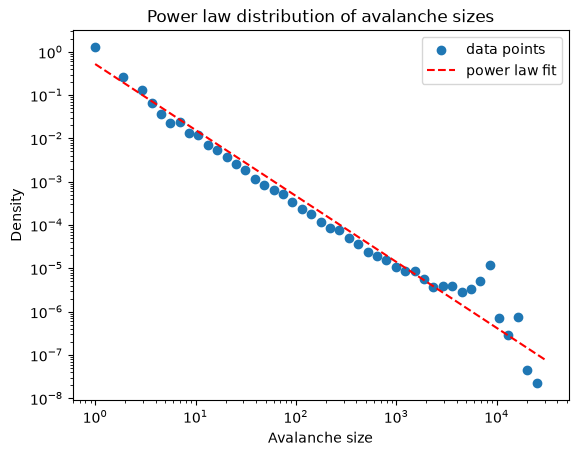

Avalanche size exponent: 0.5235382930562028


In [ ]:
random_model.remove_nodes_by_index(random_model.select_nodes_by_degree(0, raises = False))
random_model.evolve(50000, lose_probability = 0.001)
exponent = SandNet.fit_avalanche_size(random_model)
print("Avalanche size exponent: " + str(exponent))

## References

[1] Per Bak, Chao Tang, and Kurt Wiesenfeld, *Self-organized criticality: An explanation of the 1/f noise*, Phys. Rev. Lett. 59, 381 (1987)

[2] Zapperi, Stefano & Lauritsen, Kent & Stanley, H.. (1995). *Self-Organized Branching Processes: A Mean-Field Theory for Avalanches*. Physical Review Letters. 75. 10.1103/PhysRevLett.75.4071.

[3] Goh K.-I., Lee D.-S., Kahng B., Kim D., 2003, *Sandpile on Scale-Free Networks*, Physical Review Letters, 91

[4] Lee D.-S., Goh K.-I., Kahng B., Kim D., 2004, *Sandpile avalanche dynamics on scale-free networks*, Physica A: Statistical Mechanics and its Applications, 338, 84–91

[5] Goh K.-I., Kahng B., Kim D., 2001, *Universal Behavior of Load Distribution in Scale-Free Networks*, Physical Review Letters, 87